# **Stocks**

In [51]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.ticker as mtick
import seaborn as sns
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

In [52]:
def stock_finance(ticker='NVDA',periodo='2y'):
    stock=ticker
    df = yf.download(stock, period=periodo, interval="1d")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df['Returns'] = df['Close'].pct_change().dropna()
    df["MA_10"] = df["Close"].rolling(10).mean()
    df["MA_20"] = df["Close"].rolling(20).mean()
    df["MA_50"]=df["Close"].rolling(50).mean()
    df['MA_100']=df['Close'].rolling(100).mean()
    df["Volatility"] = df["Returns"].rolling(20).std()
    df["Cumulative_Returns"] = (1 + df["Returns"]).cumprod()
    df["Volume_Norm"] = df["Volume"] / df["Volume"].max()
    df['Stock']=stock
    df["BB_Middle"] = df["Close"].rolling(20).mean()
    df["BB_Std"] = df["Close"].rolling(20).std()
    df["BB_Upper"] = df["BB_Middle"] + 2 * df["BB_Std"]
    df["BB_Lower"] = df["BB_Middle"] - 2 * df["BB_Std"]
    df["equity"] = (1 + df["Returns"]).cumprod()
    return df

df=stock_finance(ticker='SPY',periodo='5y')
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Returns,MA_10,MA_20,MA_50,MA_100,Volatility,Cumulative_Returns,Volume_Norm,Stock,BB_Middle,BB_Std,BB_Upper,BB_Lower,equity
Date,,,,,,,,,,,,,,,,,,,
2021-06-08,394.402313,395.270911,392.571715,395.177507,47134300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.183680,SPY,NaN,NaN,NaN,NaN,NaN
2021-06-09,393.813934,395.317662,393.589788,395.242927,48436300,-0.001492,NaN,NaN,NaN,NaN,NaN,0.998508,0.188754,SPY,NaN,NaN,NaN,NaN,0.998508
2021-06-10,395.644470,396.597151,393.720468,395.037387,51020100,0.004648,NaN,NaN,NaN,NaN,NaN,1.003149,0.198822,SPY,NaN,NaN,NaN,NaN,1.003149
2021-06-11,396.298309,396.410383,394.906684,396.195585,45570800,0.001653,NaN,NaN,NaN,NaN,NaN,1.004807,0.177587,SPY,NaN,NaN,NaN,NaN,1.004807
2021-06-14,397.185669,397.288393,395.168262,396.410447,42358500,0.002239,NaN,NaN,NaN,NaN,NaN,1.007057,0.165069,SPY,NaN,NaN,NaN,NaN,1.007057


In [53]:
def dashboard_stocks(data=df,ticker='NVDA'):
    monthly_returns = (
    df["Returns"]
    .resample("ME")
    .apply(lambda x: (1 + x).prod() - 1))

    monthly_table = monthly_returns.to_frame("Returns")

    monthly_table["Year"] = monthly_table.index.year
    monthly_table["Month"] = monthly_table.index.strftime("%b")

    heatmap_data = monthly_table.pivot(
        index="Year",
        columns="Month",
        values="Returns"
    )

    month_order = [
        "Ene.","Feb.","Mar.","Abr.","May.","Jun.",
        "Jul.","Ago.","Set.","Oct.","Nov.","Dic."
    ]

    heatmap_data = heatmap_data.reindex(columns=month_order)
    
    yearly_returns = (
    df["Returns"]
    .resample("YE")
    .apply(lambda x: (1 + x).prod() - 1))

    yearly_returns.index = yearly_returns.index.year
    
    rolling_return = (
    df["Returns"]
    .rolling(126)
    .sum())

    rolling_vol = (
    df["Returns"]
    .rolling(126)
    .std() * np.sqrt(252)
    )
    
        
    # --- Estilo global ---
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_context("talk") # Texto más grande
    plt.rcParams['font.family'] = 'DejaVu Sans'

    fig = plt.figure(figsize=(22, 14), dpi=100)
    gs = fig.add_gridspec(4, 2, height_ratios=[2.5, 1.2, 1.2, 1.2], hspace=0.4, wspace=0.2)

    # ==================================
    # 1. EQUITY CURVE + DRAWDOWN
    # ==================================
    equity = df['equity'].dropna()
    ax1 = fig.add_subplot(gs[0, :])

    # Equity
    ax1.plot(equity.index, equity, lw=2.5, color='#1f77b4', label='Strategy')
    ax1.set_title("Strategy Performance", fontsize=18, weight='bold', pad=15)
    ax1.set_ylabel("Portfolio Value ($)", fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper left')

    # Drawdown en eje secundario
    dd = df['equity'] / df['equity'].cummax() - 1
    ax1_dd = ax1.twinx()
    ax1_dd.fill_between(df.index, dd*100, 0, color='red', alpha=0.2, label='Drawdown')
    ax1_dd.set_ylabel('Drawdown (%)', color='red', fontsize=12)
    ax1_dd.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax1_dd.legend(loc='upper right')
    ax1_dd.set_ylim(dd.min()*100*1.1, 5)

    # Métricas clave en texto
    total_ret = (equity.iloc[-1] / equity.iloc[0] - 1) * 100
    cagr = ((equity.iloc[-1] / equity.iloc[0]) ** (252/len(equity)) - 1) * 100
    max_dd = dd.min() * 100
    ax1.text(0.02, 0.75, f'CAGR: {cagr:.1f}% | Total: {total_ret:.1f}% | Max DD: {max_dd:.1f}%', 
            transform=ax1.transAxes, fontsize=11, bbox=dict(facecolor='white', alpha=0.8))

    # ==================================
    # 2. MONTHLY HEATMAP
    # ==================================
    ax2 = fig.add_subplot(gs[1, 0])

    sns.heatmap(
        heatmap_data * 100,
        annot=True,
        fmt=".1f",
        cmap="RdYlGn", # Rojo=malo, Verde=bueno
        center=0,
        linewidths=0.5,
        cbar_kws={'label': 'Return %'},
        ax=ax2
    )
    ax2.set_title("Monthly Returns (%)", fontsize=14, weight='bold')
    ax2.set_xlabel("")
    ax2.set_ylabel("")

    # ==================================
    # 3. YEARLY RETURNS con etiquetas
    # ==================================
    ax3 = fig.add_subplot(gs[1, 1])

    colors = ['#2ca02c' if x > 0 else '#d62728' for x in yearly_returns]
    bars = ax3.barh(
        yearly_returns.index.astype(str),
        yearly_returns.values * 100,
        color=colors,
        edgecolor='black',
        linewidth=0.7
    )

    # Etiquetas de % al final de cada barra
    for bar, val in zip(bars, yearly_returns.values * 100):
        width = bar.get_width()
        label_x = width + 1 if width > 0 else width - 1
        ha = 'left' if width > 0 else 'right'
        ax3.text(label_x, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}%', ha=ha, va='center', fontsize=10, weight='bold')

    ax3.axvline(0, color="black", lw=1)
    ax3.set_title("Yearly Returns (%)", fontsize=14, weight='bold')
    ax3.set_xlabel("Return %")
    ax3.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax3.grid(axis='x', alpha=0.3)

    # ==================================
    # 4. DISTRIBUTION con stats
    # ==================================
    ax4 = fig.add_subplot(gs[2, 0])

    n, bins, patches = ax4.hist(
        monthly_returns * 100,
        bins=25,
        color='#1f77b4',
        edgecolor='black',
        alpha=0.7
    )

    # Colorea colas
    for i, patch in enumerate(patches):
        if bins[i] < monthly_returns.mean()*100 - monthly_returns.std()*100:
            patch.set_facecolor('#d62728')
        elif bins[i] > monthly_returns.mean()*100 + monthly_returns.std()*100:
            patch.set_facecolor('#2ca02c')

    ax4.axvline(monthly_returns.mean()*100, color='red', ls='--', lw=2, label=f'Mean: {monthly_returns.mean()*100:.2f}%')
    ax4.axvline(0, color='black', lw=1)
    ax4.set_title("Distribution Monthly Returns", fontsize=14, weight='bold')
    ax4.set_xlabel("Monthly Return %")
    ax4.xaxis.set_major_formatter(mtick.PercentFormatter())
    ax4.legend()

    # Stats en caja
    skew = stats.skew(monthly_returns.dropna())
    kurt = stats.kurtosis(monthly_returns.dropna())
    ax4.text(0.98, 0.95, f'Skew: {skew:.2f}\nKurt: {kurt:.2f}', 
            transform=ax4.transAxes, ha='right', va='top',
            bbox=dict(facecolor='white', alpha=0.8), fontsize=10)

    # ==================================
    # 5. Q-Q PLOT
    # ==================================
    ax5 = fig.add_subplot(gs[2, 1])

    stats.probplot(monthly_returns.dropna(), dist="norm", plot=ax5)
    ax5.get_lines()[0].set_markerfacecolor('#1f77b4')
    ax5.get_lines()[0].set_markeredgecolor('black')
    ax5.get_lines()[1].set_color('red')
    ax5.get_lines()[1].set_linewidth(2)
    ax5.set_title("Q-Q Plot vs Normal", fontsize=14, weight='bold')
    ax5.grid(True, alpha=0.3)

    # ==================================
    # 6. ROLLING STATS con Sharpe
    # ==================================
    ax6 = fig.add_subplot(gs[3, :])

    ax6.plot(rolling_return.index, rolling_return*100, label="Rolling Return (6M)", lw=2, color='#2ca02c')
    ax6.plot(rolling_vol.index, rolling_vol*100, label="Rolling Volatility (6M)", lw=2, color='#ff7f0e')

    # Rolling Sharpe en eje secundario
    rolling_sharpe = (rolling_return / rolling_vol) * np.sqrt(12)
    ax6_sharpe = ax6.twinx()
    ax6_sharpe.plot(rolling_sharpe.index, rolling_sharpe, label="Rolling Sharpe", lw=2, color='#9467bd', alpha=0.6)
    ax6_sharpe.axhline(1.0, color='gray', ls='--', lw=1, label='Sharpe=1')
    ax6_sharpe.set_ylabel('Sharpe Ratio', color='#9467bd')
    ax6_sharpe.legend(loc='upper right')

    ax6.set_ylabel('Return/Vol %', fontsize=12)
    ax6.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax6.legend(loc='upper left')
    ax6.set_title("Rolling Statistics (6 Months)", fontsize=14, weight='bold')
    ax6.grid(True, alpha=0.3)

    fig.suptitle(f'{ticker} Strategy Tearsheet', fontsize=20, weight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

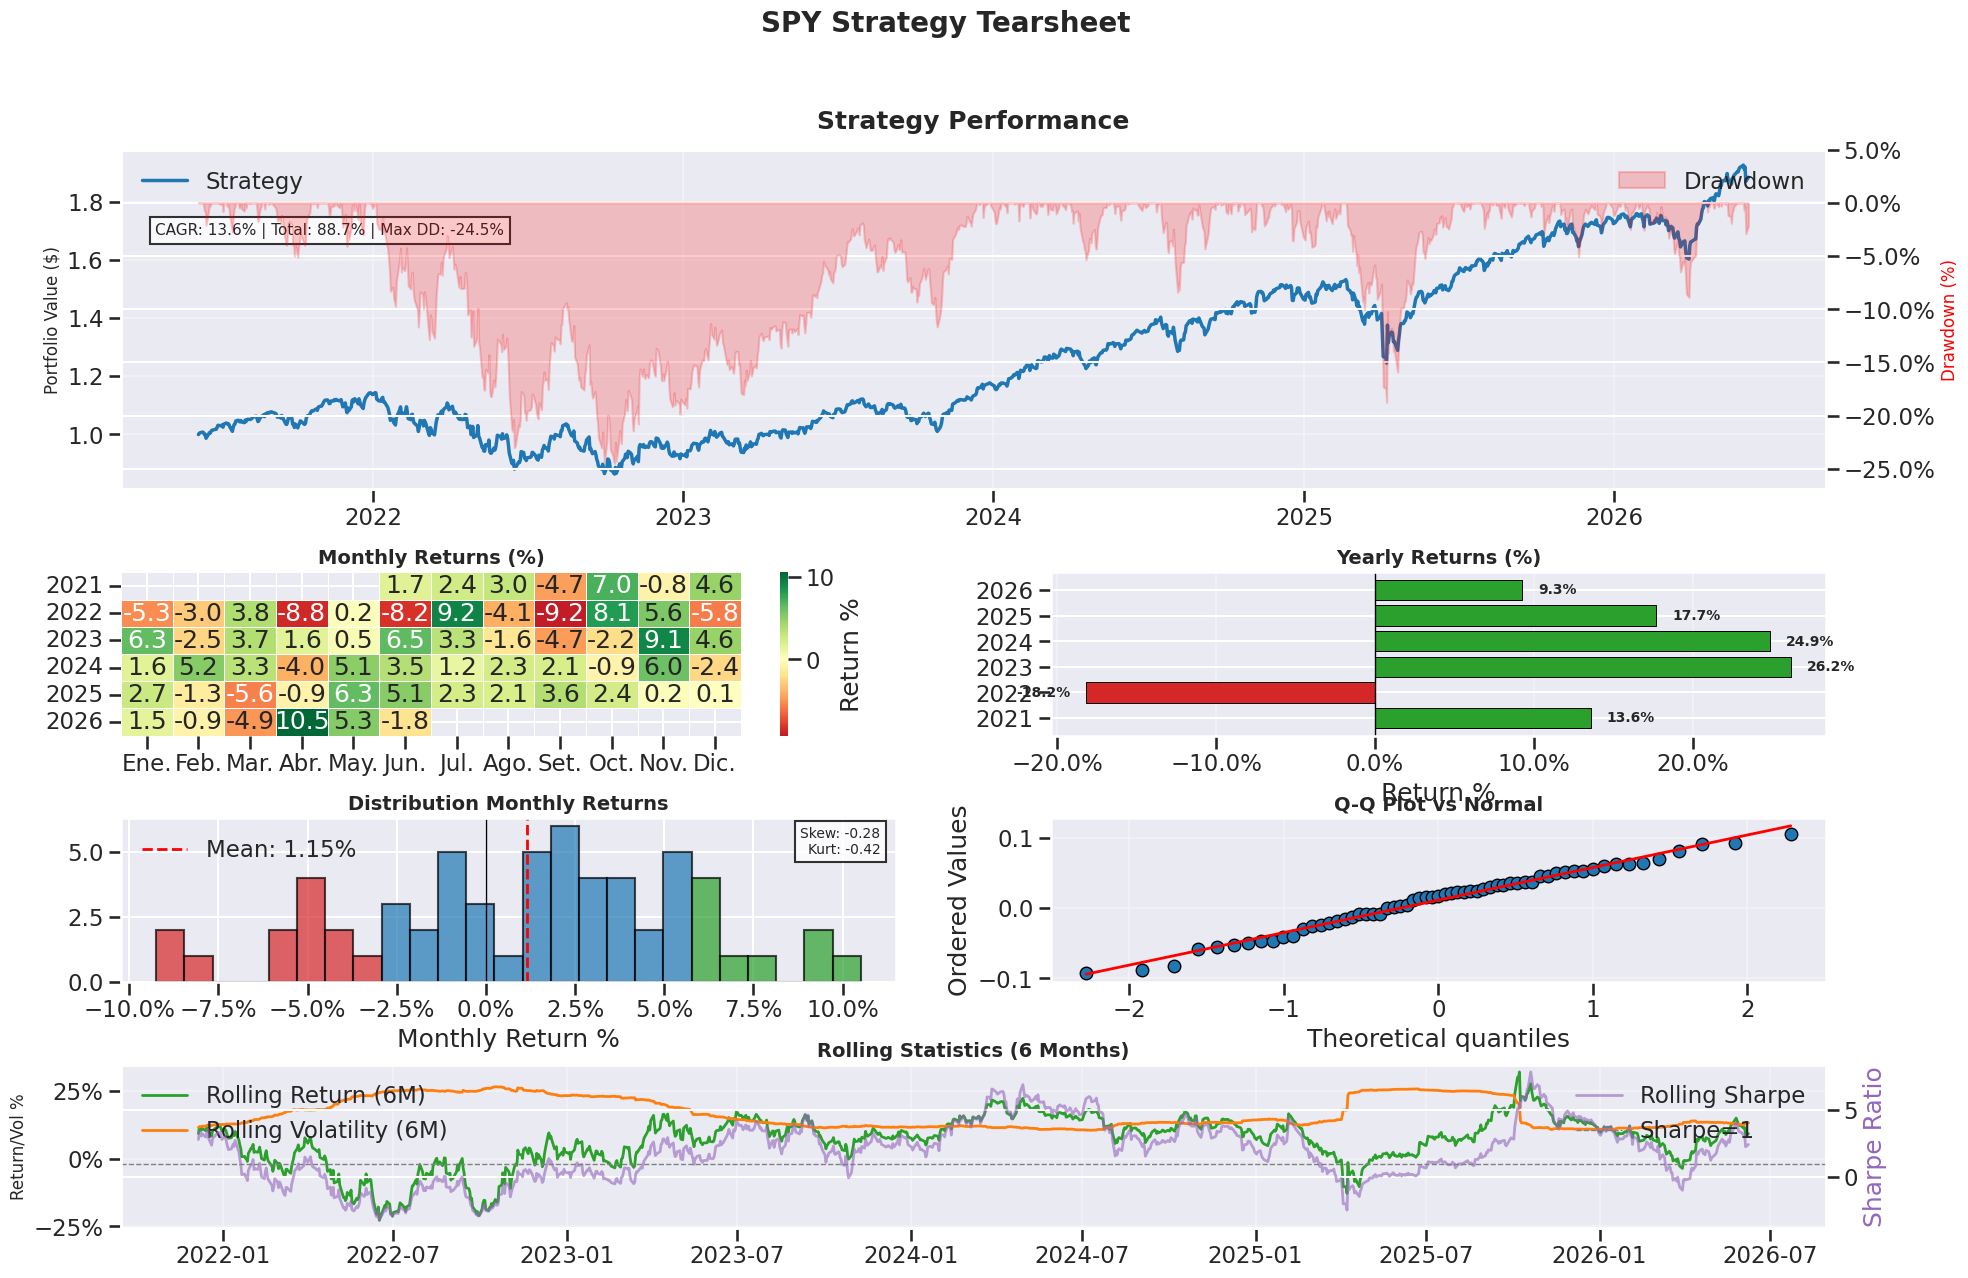

In [54]:
dashboard_stocks(data=df,ticker='SPY')